# **Vanilla Generative Adversarial Generative Networks**

**Goal**: Exploring GAN - A system of two neural networks that mimics a collection of existing images. 

**Objectives**

- Read in medical images, particularly brain MRIs.
- Create the two adversarial networks.
- Create a discriminator to tell real images from fake.
- Create a generator to create new fake images.
- Train the networks against each other.
- Generate new images with the trained generator.

In [38]:
import datetime
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np 
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

In [39]:
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("numpy version : ", np.__version__)

!python --version

torch version :  2.2.2+cpu
torchvision version :  0.17.2+cpu
numpy version :  1.26.3
Python 3.12.1


In [40]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Loading Data**

- Creating training directories.

In [41]:
data_dir = Path("data")
images_dir = data_dir / "gan_training_images"
print(images_dir)

data\gan_training_images


**Sample images**

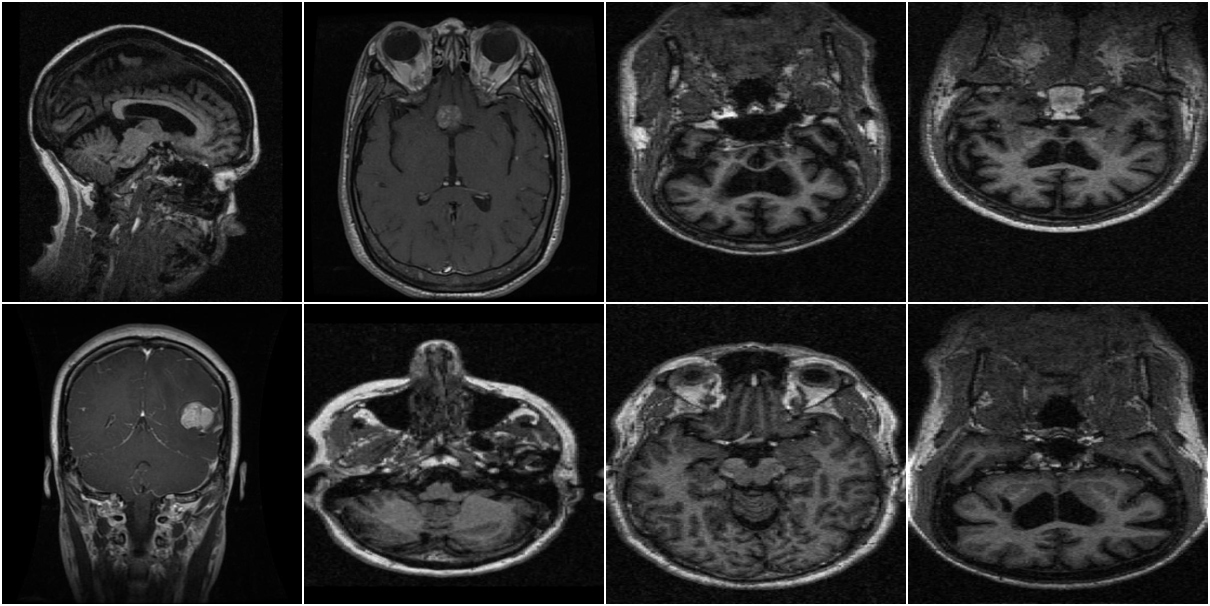

In [42]:
image_list = list(images_dir.glob("*.jpg"))

image_sample = random.sample(image_list, 8)

resize = transforms.Resize((300, 300))
gray = transforms.Grayscale()

images = []
for file in image_sample:
    img = read_image(str(file))
    img = gray(resize(img))
    images.append(img)

real_grid = make_grid(images, nrow=4, pad_value=255.0)
torchvision.transforms.ToPILImage()(real_grid)

**Transformations to resize and convert to tensor**

In [43]:
IMAGE_SIZE = 64

transformations = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ]
)

transformations

Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

Creating an ImageFolder using our transformations, and a DataLoader:

In [44]:
batch_size = 128

dataset = datasets.ImageFolder(data_dir, transformations)
dataloader = DataLoader(dataset, batch_size, shuffle=True)

single_batch = next(iter(dataloader))[0]
print(f"Batches have shape: {single_batch.shape}")

Batches have shape: torch.Size([128, 1, 64, 64])


## **Generative Adversarial Networks**

- Working with GAN requires two networks; generator - attempts to make new images, and discriminator - tries to tell if an image is real or created by a generator. The GAN process pits the two against each other.

**Discriminator**

An image classifier. We flatten our image down to a vector and use standard Linear (fully connected layers) instead of using convolutional network. We use LeakyReLU(0.25), except for the final layer.

We're trying to tell real from fake images. So, we produce an output with one vaue for each image. With only one output, we'll need the Sigmoid to get a result between 0 and 1, instead of SoftMax.

In summary, the network architecture is as follows:


- Flatten image
- Linear layer with 1024 neurons
- LeakyReLU(0.25)
- Linear layer with 512 neurons
- LeakyReLU(0.25)
- Linear Layer with 256 neurons
- LeakyReLU(0.25)
- Linear layer to produce one output (1 neuron)
- Sigmoid



First few layers:

In [45]:
discriminator = nn.Sequential()
discriminator.append(nn.Flatten())

# Input images are 1 * 64 * 64 = 4096 pixels after flattening
discriminator.append(nn.Linear(1 * 64 * 64, 1024))
discriminator.append(nn.LeakyReLU(0.25))

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=4096, out_features=1024, bias=True)
  (2): LeakyReLU(negative_slope=0.25)
)

In [46]:
discriminator(single_batch).shape

torch.Size([128, 1024])

More Layers:

In [47]:
discriminator.append(nn.Linear(1024, 512))
discriminator.append(nn.LeakyReLU(0.25))
discriminator.append(nn.Linear(512, 256))
discriminator.append(nn.LeakyReLU(0.25))

discriminator

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=4096, out_features=1024, bias=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): LeakyReLU(negative_slope=0.25)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): LeakyReLU(negative_slope=0.25)
)

In [48]:
print("Getting results with following shape:")
print(discriminator(single_batch).shape)

Getting results with following shape:
torch.Size([128, 256])


Output Layer:

In [49]:
discriminator.append(nn.Linear(256, 1))

print("Getting results with following shape:")
print(discriminator(single_batch).shape)

Getting results with following shape:
torch.Size([128, 1])


In [50]:
discriminator.append(nn.Sigmoid())

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=4096, out_features=1024, bias=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): LeakyReLU(negative_slope=0.25)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): LeakyReLU(negative_slope=0.25)
  (7): Linear(in_features=256, out_features=1, bias=True)
  (8): Sigmoid()
)

**Generator**

Creates images out of nothing. We start by creating some random numbers. We create a sammler noise vector, basically an array of random numbers of some size, say 100. 

We then run a process similar to the discriminator in reverse.  Instead of getting progressively smaller numbers of neurons per layer, we get progressively more, untill we have 4096 we need for a `1 X 64 X 64` image. we reshape into an image, and output it.

The generator can be broken down into three unsampling stages. In each of the stages, the size of the vector is expanded, with a Linear layer with more outputs than inputs. The bias term is turned off. 

The result will be a `BatchNorm1d`, that acts to speed up the training and make it go smoother. 

In [51]:
noise_size = 100
first_stage_size = 256

generator = nn.Sequential()
generator.append(nn.Linear(noise_size, first_stage_size, bias=False))

# The batch norm doesn't change the shape, but needs the number of inputs
# The 0.8 adjusts its behavior, we'll use the same value for all stages
generator.append(nn.BatchNorm1d(first_stage_size, 0.8))
generator.append(nn.LeakyReLU(0.25))

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.25)
)

The above takes our 100 random numbers and gives us 256. Next is to get a batch of random numbers to verify.

In [52]:
# Create a batch of random numbers
random_number_sample = torch.randn(batch_size, noise_size)
random_number_sample.shape

torch.Size([128, 100])

Next is to run the current generator with just the first upsampling on the random_number_sample.

In [53]:
first_upscale = generator(random_number_sample)

print(f"After first upscale: {first_upscale.shape}")

After first upscale: torch.Size([128, 256])


Second unsampling:

In [54]:
second_stage_size = 512

# Add second upsampling stage
generator.append(nn.Linear(first_stage_size, second_stage_size, bias=False))
generator.append(nn.BatchNorm1d(second_stage_size, 0.8))
generator.append(nn.LeakyReLU(0.25))

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=256, out_features=512, bias=False)
  (4): BatchNorm1d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.25)
)

In [55]:
generator(random_number_sample).shape

torch.Size([128, 512])

Third unsampling.

In [56]:
third_stage_size = 1024

# Add third upsampling stage
generator.append(nn.Linear(second_stage_size, third_stage_size, bias=False))
generator.append(nn.BatchNorm1d(third_stage_size, 0.8))
generator.append(nn.LeakyReLU(0.25))

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=256, out_features=512, bias=False)
  (4): BatchNorm1d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.25)
  (6): Linear(in_features=512, out_features=1024, bias=False)
  (7): BatchNorm1d(1024, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.25)
)

In [57]:
generator(random_number_sample).shape

torch.Size([128, 1024])

Final Layer

In [58]:
# Add the final linear layer
output_size = 1 * 64 * 64
generator.append(nn.Linear(third_stage_size, output_size, bias=False))

generator

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=256, out_features=512, bias=False)
  (4): BatchNorm1d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.25)
  (6): Linear(in_features=512, out_features=1024, bias=False)
  (7): BatchNorm1d(1024, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.25)
  (9): Linear(in_features=1024, out_features=4096, bias=False)
)

Adding activation function:

In [59]:
generator.append(nn.Tanh())
generator.append(nn.Unflatten(1, [1, 64, 64]))

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.25)
  (3): Linear(in_features=256, out_features=512, bias=False)
  (4): BatchNorm1d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.25)
  (6): Linear(in_features=512, out_features=1024, bias=False)
  (7): BatchNorm1d(1024, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.25)
  (9): Linear(in_features=1024, out_features=4096, bias=False)
  (10): Tanh()
  (11): Unflatten(dim=1, unflattened_size=[1, 64, 64])
)

Output Shape

In [60]:
generator_output = generator(random_number_sample) 
output_shape = generator_output.shape

print(f"Generator output shape: {output_shape}")

Generator output shape: torch.Size([128, 1, 64, 64])


A look at a sample random images/noise:

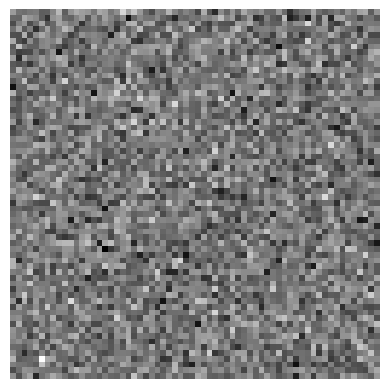

In [61]:
plt.imshow(generator_output[0, 0].detach(), cmap="gray")
plt.axis("off");

**Training the GAN System**

Training two networks against each other. 

It's kept simple, and the model at each epoch regardless of loss values.

Making a seperate dictionary for each time the epoch runs. 

In [62]:
# Gets the time in the order year-month-day_hour-minute-second
now = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
now

'2025-04-29_17-34-19'

Creating a path variable to the directory runs, and a subdirectory named using the now variable using `pathlib` library.

In [63]:
runs_dir = Path("runs")
now_dir = runs_dir / now

# Create the directories with mkdir
now_dir.mkdir(parents=True, exist_ok=True)
print(f'directory "{now_dir}" exists: {now_dir.exists()}')

directory "runs\2025-04-29_17-34-19" exists: True


Optimizer Params.

In [64]:
lr = 0.0002
betas = (0.5, 0.999)

disc_opt = torch.optim.AdamW(params=discriminator.parameters(), lr=lr, betas=betas)
gen_opt = torch.optim.AdamW(params=generator.parameters(), lr=lr, betas=betas)

n_disc_pars = len(disc_opt.param_groups[0]["params"])
n_gen_pars = len(gen_opt.param_groups[0]["params"])

print(f"disc_opt sees {n_disc_pars} parameters, should be 8")
print(f"get_opt sees {n_gen_pars} parameters, should be 10")

disc_opt sees 8 parameters, should be 8
get_opt sees 10 parameters, should be 10


Loss function:

In [65]:
loss_function = nn.BCELoss()

Model Transfer to device

In [66]:
# discriminator to device
discriminator.to(device)
# generator to device
generator.to(device)
disc_dev = next(generator.parameters()).device.type
gen_dev = next(generator.parameters()).device.type

print(f"Discriminator on {disc_dev}")
print(f"Generator on {gen_dev}")

Discriminator on cpu
Generator on cpu


**Generating Images**

In [67]:
def make_random_images(batch_size, generator=generator):
    # Create a batch of random numbers
    random_number_sample = torch.randn(batch_size, 100)
    random_number_sample = random_number_sample.to(device)
    generator.eval()

    # Run the generator on the random numbers
    generator_output = generator(random_number_sample)

    return generator_output

In [68]:
# Test run
sample_images = make_random_images(batch_size, generator)
print(f"Output shape: {sample_images.shape}")

Output shape: torch.Size([128, 1, 64, 64])


Display sample images

In [69]:
def display_images(image_tensor, n_to_display=6):
    grid = make_grid(image_tensor[:n_to_display], nrow=6, normalize=True)
    img_out = transforms.ToPILImage()(grid)
    plt.figure(figsize=(15, 7.5))
    plt.imshow(img_out)
    plt.axis("off")
    plt.show()

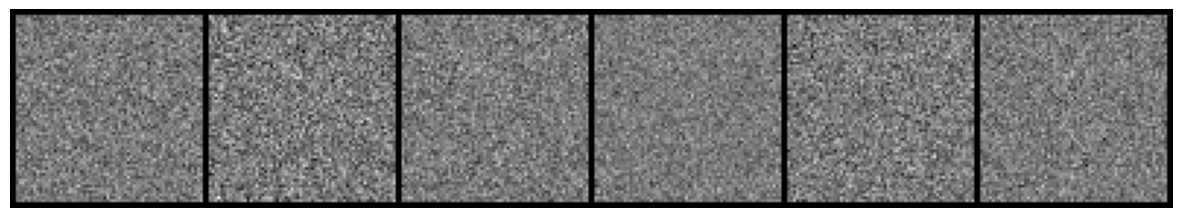

In [70]:
display_images(sample_images)

Training Setup

Training will be a number of epochs. Each epoch is one pass through the real data, broken into multiple minibatches. Therefore, the training process will be a loop over epochs, and each of those epochs is a loop over batches. Each step in the training process will follow the following pattern:

- Take a batch of real images, label them all
- Train the discriminator one step on the real images
- Have the generator create a batch of fake images, label them all
- Train the discriminator one step on the fake images
- Get the predictions of the discriminator on the fake images
- Train the generator to trick the discriminator

In [71]:
def perform_batch_step(
    discriminator,
    generator,
    real_data_batch,
    loss_function,
    disc_opt,
    gen_opt,
    device=device,
):
    """Perform a single batch step"""

    # Set real and fake labels
    real_label_val = 1.0
    fake_label_val = 0.0

    # Send real data to device
    # This pulls out just the images, we'll make our own label
    real_images = real_data_batch[0].to(device)

    # Create labels: all 1.0 for real data
    actual_batch_size = real_images.size(0)
    real_label = torch.full((actual_batch_size, 1), real_label_val, device=device)

    # Get the derivative for the real images
    disc_opt.zero_grad()
    real_output = discriminator(real_images)
    real_loss = loss_function(real_output, real_label)
    real_loss.backward()

    # Generate fake images using the generator
    fake_images = make_random_images(actual_batch_size, generator)
    # label all fake images as 0.0
    fake_label = torch.full((actual_batch_size, 1), fake_label_val, device=device)

    # Get the derivative for the fake images
    fake_output = discriminator(fake_images.detach())
    fake_loss = loss_function(fake_output, fake_label)
    fake_loss.backward()

    # Discriminator total loss
    disc_loss = real_loss.item() + fake_loss.item()

    # Train the discriminator
    disc_opt.step()

    # Get derivative for the generator
    # We're adjusting the generator to make the
    # discriminator think fake images are real
    gen_opt.zero_grad()
    trick_output = discriminator(fake_images)
    trick_loss = loss_function(trick_output, real_label)
    trick_loss.backward()

    # Train the generator
    gen_opt.step()

    # Generator loss
    gen_loss = trick_loss.item()

    # Return discriminator loss and generator loss for logging
    return gen_loss, disc_loss

At each epoch the process will:


- Loop over our data loader
- For each batch, run it through the perform_batch_step function
- Checkpoint both the discriminator and the generator
- Generate a batch of images to see the model's progress
- Print a summary of the model's losses and display the images


In [72]:
def save_models(discriminator, generator, epoch, directory):
    # Get discriminator state dictionary
    disc_state_dict = discriminator.state_dict()

    disc_filename = directory / f"discriminator_{epoch}.pth"

    # Save discriminator save dictionary to `disc_filename`
    torch.save(disc_state_dict, disc_filename)

    # Get generator state dictionary
    gen_state_dict = generator.state_dict()

    gen_filename = directory / f"generator_{epoch}.pth"

    # Save generator save dictionary to `gen_filename`
    torch.save(gen_state_dict, disc_filename)